# Hybrid Automatic Repeat Request (HARQ) in 5G with Sionna

This tutorial demonstrates how HARQ with redundancy versions (RVs) is used in 5G NR, and how to model it in Sionna. HARQ is a fundamental mechanism to improve reliability over unreliable wireless links, combining forward error correction and retransmission strategies.

## 🔄 What is HARQ?

Hybrid Automatic Repeat Request (HARQ) is a mechanism used in wireless communications, particularly 5G, to enhance the reliability of data transmission over noisy and fading channels. It combines two techniques:

- **Forward Error Correction (FEC)**: Adds redundancy to transmitted data so that errors can be corrected at the receiver.
- **Automatic Repeat Request (ARQ)**: Requests retransmission of data if errors cannot be corrected.

In HARQ, when the initial transmission cannot be decoded, the receiver stores the soft information (LLRs) and combines it with new retransmissions. This is known as **soft combining**, and significantly improves decoding success probability.

## 🧩 Redundancy Versions (RVs)

5G uses **Redundancy Versions (RVs)** to send different parts of the codeword in each retransmission. Instead of repeating the same bits, the encoder transmits different, complementary subsets selected via rate matching from a circular buffer. This increases decoding diversity and improves the effectiveness of soft combining.

**RV0** typically includes **most of the systematic bits and a portion of the parity bits**, providing the highest decoding reliability when transmitted first. Subsequent RVs (RV1–RV3) contain primarily parity bits, each selected from different sections of the buffer to maximize the value of retransmissions.

Common HARQ transmission orders include:

- `["rv0", "rv2"]`
- `["rv0", "rv2", "rv3", "rv1"]`
- Even `["rv0", "rv0"]` in case of severe interference during the first transmission

RVs are defined by their start positions within the rate-matching buffer and vary by specification (3GPP TS 38.212).

## 📊 Figure 1: HARQ Timeline with Retransmissions

The following figure shows a simplified HARQ process where retransmissions are triggered after decoding failures and new RVs are sent. Soft information is accumulated until decoding succeeds.



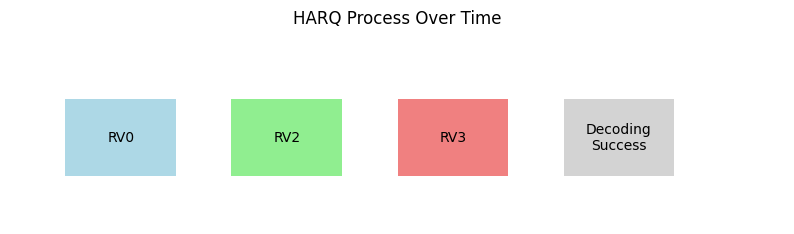

In [49]:
# --- Figure: Generate HARQ transmission timeline (not part of Sionna) ---

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.5))
rounds = ["RV0", "RV2", "RV3", "Decoding\nSuccess"]
colors = ["lightblue", "lightgreen", "lightcoral", "lightgray"]

offset = 0.5  # shift right
for i, label in enumerate(rounds):
    ax.broken_barh([(i * 1.5 + offset, 1)], (0.5, 0.8), facecolors=colors[i])
    ax.text(i * 1.5 + offset + 0.5, 0.9, label, ha='center', va='center', fontsize=10)

ax.set_ylim(0, 2)
ax.set_xlim(0, 7)
ax.axis("off")
ax.set_title("HARQ Process Over Time", fontsize=12)
plt.show()


## 🧩 Figure 2: Rate Matching and RV Selection in Circular Buffer

This polar plot visualizes how RVs correspond to different segments of the circular buffer. Each RV selects a different offset in the encoded codeword to send complementary redundancy bits.

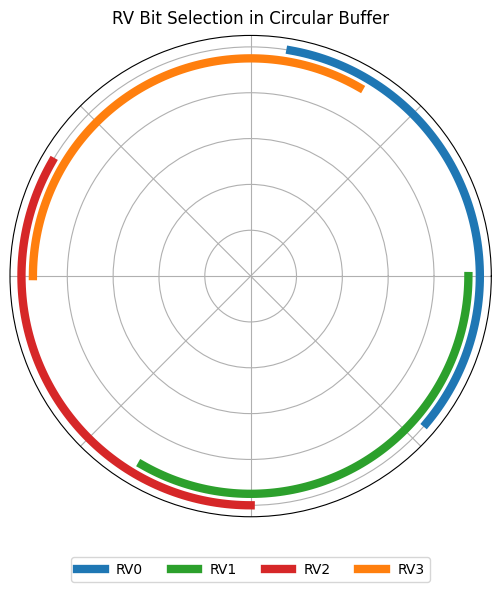

In [50]:
# --- Figure: Visualize RV bit selection from circular buffer (illustrative only) ---

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})

n_cb = 360
rv_len = 120  # degrees
rv_positions_deg = {
    "RV0": 80,     # just after 12 o'clock
    "RV1": 0,      # 3 o'clock
    "RV2": -90,    # 6 o'clock
    "RV3": 180     # 9 o'clock
}
radii = [1.0, 0.95, 1.0, 0.95]  # radii for each RV
colors = ['tab:blue', 'tab:green', 'tab:red', 'tab:orange']

for i, (rv, start_deg) in enumerate(rv_positions_deg.items()):
    theta_start = np.radians(start_deg)
    theta_end = theta_start - 2 * np.pi * rv_len / 360  # clockwise
    theta = np.linspace(theta_start, theta_end, 100)
    r = np.ones_like(theta) * radii[i]
    ax.plot(theta, r, lw=6, label=rv, color=colors[i])

ax.set_rlim(0, 1.05)  # set radial limits

ax.set_theta_zero_location("E")   # 0° at East
ax.set_theta_direction(1)        # clockwise
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_title("RV Bit Selection in Circular Buffer", va='bottom', fontsize=12)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=4)
plt.tight_layout()
plt.show()


## 🔁 Figure 3: LLR Soft Combining Across RVs

This plot shows how soft information from multiple RVs is combined. The final LLRs are the sum of individual RVs, resulting in stronger confidence for each bit position.

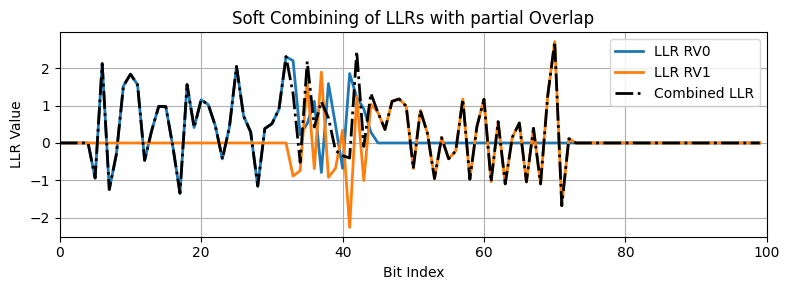

In [51]:
# --- Figure: Simulated soft combining of overlapping RVs (illustrative) ---

import numpy as np
import matplotlib.pyplot as plt

n_cb = 100
rv_len = 40

rv0_start = 5
rv1_start = 33

llr_rv0 = np.zeros(n_cb)
llr_rv0[rv0_start:rv0_start+rv_len] = np.random.normal(loc=0.5, scale=1.0, size=rv_len)

llr_rv1 = np.zeros(n_cb)
llr_rv1[rv1_start:rv1_start+rv_len] = np.random.normal(loc=0.3, scale=1.0, size=rv_len)

llr_combined = llr_rv0 + llr_rv1

plt.figure(figsize=(8, 3))
plt.plot(llr_rv0, label="LLR RV0", lw=2.0)
plt.plot(llr_rv1, label="LLR RV1", lw=2.0)
plt.plot(llr_combined, label="Combined LLR", lw=2.0, color='black', ls='-.')
plt.xlim(0, 100)

plt.title("Soft Combining of LLRs with partial Overlap")
plt.xlabel("Bit Index")
plt.ylabel("LLR Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 🧪 Simulating HARQ in Sionna

In a Sionna-based HARQ simulation, you would typically:

1. Encode the LDPC codeword once.
2. Select multiple RVs using rate matching.
3. Transmit each RV through the channel (sequentially or in parallel).
4. Recover full-size LLRs by reversing the RV selection.
5. Combine LLRs and decode.

Sionna provides the tools needed to build this pipeline manually or in a modular way.

This allows exploration of real HARQ behavior including custom RV patterns, SNR variations, or soft combining strategies such as scaling and clipping.

## Table of Contents
* [GPU Configuration and Imports](#GPU-Configuration-and-Imports)
* [BLER Performance of 5G LDPC with HARQ](#BLER-Performance-of-5G-LDPC-HARQ)

## GPU Configuration and Imports

In [52]:
import os
import tensorflow as tf

# Configure GPU/CPU automatically
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("CUDA GPU detected - using GPU for computation")
    # Use first GPU and allow memory growth
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
    os.environ["CUDA_VISIBLE_DEVICES"] = "0"
else:
    print("No CUDA GPU detected - using CPU for computation")
    tf.config.set_visible_devices([], 'GPU')
    os.environ["CUDA_VISIBLE_DEVICES"] = ""

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e 

# For testing in eager mode
tf.config.run_functions_eagerly(True)

# Set random seed for reproducibility
sionna.phy.config.seed = 42

# Load the required Sionna components
from sionna.phy import Block
from sionna.phy.mapping import Constellation, Mapper, Demapper, BinarySource
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
from sionna.phy.utils import count_block_errors, ebnodb2no, PlotBER
from sionna.phy.channel import AWGN

No CUDA GPU detected - using CPU for computation


In [53]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time # for throughput measurements

## BLER Performance of 5G LDPC HARQ

For k = 64 and n = 150, we simulate 4 scenarios with increasing numbers of retransmissions:
- RV0 only (no retransmissions)
- RV0 + RV2
- RV0 + RV2 + RV3
- RV0 + RV2 + RV3 + RV1

Let us define the system model first. We use encoder and decoder as input parameter such that the model remains flexible w.r.t. the coding scheme.

In [54]:
class System_Model(Block):
    """System model for channel coding BER simulations.
    
    This model allows to simulate BERs over an AWGN channel with
    QAM modulation. Arbitrary FEC encoder/decoder layers can be used to 
    initialize the model.
    
    Parameters
    ----------
        k: int
            number of information bits per codeword.
        
        n: int 
            codeword length.
        
        num_bits_per_symbol: int
            number of bits per QAM symbol.
            
        rv_set: list of str
            A list of redundancy versions (RV) to be used for the simulation.
            The RVs are used to set the FEC encoder and decoder to the correct
            redundancy version. Defaults to ['rv0'].
            
        demapping_method: str
            A string denoting the demapping method. Can be either "app" or "maxlog".
            
        sim_esno: bool  
            A boolean defaults to False. If true, no rate-adjustment is done for the SNR calculation.

    Input
    -----
        batch_size: int or tf.int
            The batch_size used for the simulation.
        
        ebno_db: float or tf.float
            A float defining the simulation SNR.
            
    Output
    ------
        (u, u_hat):
            Tuple:
        
        u: tf.float32
            A tensor of shape `[batch_size, k] of 0s and 1s containing the transmitted information bits.

        u_hat: tf.float32
            A tensor of shape `[batch_size, k] of 0s and 1s containing the estimated information bits.
    """
    def __init__(self,
                 k,
                 n,
                 num_bits_per_symbol,
                 rv_set=['rv0'],
                 demapping_method="app"):

        super().__init__()
        
        # store values internally
        self.k = k
        self.n = n
        
        # number of bit per QAM symbol
        self.num_bits_per_symbol = num_bits_per_symbol

        # init components
        self.source = BinarySource()
       
        # initialize mapper and demapper for constellation object
        self.constellation = Constellation("qam",
                                num_bits_per_symbol=self.num_bits_per_symbol)
        self.mapper = Mapper(constellation=self.constellation)
        self.demapper = Demapper(demapping_method,
                                 constellation=self.constellation)
        
        # the channel can be replaced by more sophisticated models
        self.channel = AWGN()

        # 5G LDPC codes with 20 BP iterations (prune_pcm not yet supported
        # in HARQ mode)
        self.encoder = LDPC5GEncoder(k=k, n=n)
        self.decoder = LDPC5GDecoder(self.encoder, num_iter=20,
                                     prune_pcm=False, harq_mode=True)

        # redundancy version set
        self.rv_set = rv_set

    @tf.function() # enable graph mode for increased throughputs
    def call(self, batch_size, ebno_db):

        # calculate noise variance (values are Es/No)
        no = ebnodb2no(ebno_db, num_bits_per_symbol=1, coderate=1)

        u = self.source([batch_size, self.k]) # generate random data
        c = self.encoder(u, rv=self.rv_set) # explicitly encode
        x = self.mapper(c) # map c to symbols x
        y = self.channel(x, no) # transmit over AWGN channel
        llr_ch = self.demapper(y, no) # demap y to LLRs
        u_hat = self.decoder(llr_ch, rv=self.rv_set)  # decoder

        return u, u_hat

Run the BLER simulation for each scenario, with progressively more retransmissions. And plot the results.

In [55]:
k = 64 # number of information bits per codeword
n = 150 # desired codeword length
rv_set = ['rv0', 'rv2', 'rv3', 'rv1']  # redundancy version set for HARQ
rv_set_upper = [rv.upper() for rv in rv_set]  # upper-case for plotting

num_bits_per_symbol = 2 # QPSK
ebno_db = np.arange(-1.0, 3.5, 0.5) # sim SNR range 
ebno_offset = np.array([0.0, -4.0, -6.0, -7.0]) # offset for each number of retries

bler_plot128 = PlotBER(f"5G LDPC BP-20 - HARQ Performance (k={k}, n={n})")

for i in range(len(rv_set)):
    # run BLER simulations for each number of retransmission attempts:
    # rv0; rv0+rv2; rv0+rv2+rv3; rv0+rv2+rv3+rv1.
    # In each scenario, the first i+1 redundancy versions are used.
    model = System_Model(k=k,
                         n=n,
                         num_bits_per_symbol=num_bits_per_symbol,
                         rv_set=rv_set[0:i+1])  # use the first i+1 redundancy versions

    # the first argument must be a callable (function) that yields u and u_hat for batch_size and ebno
    bler_plot128.simulate(model, # the function have defined previously
                          ebno_dbs=ebno_db + ebno_offset[i], # SNR to simulate
                          legend=" + ".join(rv_set_upper[0:i+1]), # legend string for plotting
                          max_mc_iter=100, # run 100 Monte Carlo runs per SNR point
                          num_target_block_errors=100, # continue with next SNR point after 1000 bit errors
                          batch_size=10000, # batch-size per Monte Carlo run
                          soft_estimates=False, # the model returns hard-estimates
                          early_stop=True, # stop simulation if no error has been detected at current SNR point
                          show_fig=False, # we show the figure after all results are simulated
                          add_bler=True, # in case BLER is also interesting
                          forward_keyboard_interrupt=True); # should be True in a loop

# and show the figure
bler_plot128(ylim=(1e-3, 1), show_ber=False, show_bler=True)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -1.0 | 1.8812e-01 | 8.7550e-01 |      120397 |      640000 |         8755 |       10000 |         5.5 |reached target block errors
     -0.5 | 1.4772e-01 | 7.3170e-01 |       94538 |      640000 |         7317 |       10000 |         3.7 |reached target block errors
      0.0 | 1.0402e-01 | 5.3310e-01 |       66575 |      640000 |         5331 |       10000 |         4.0 |reached target block errors


KeyboardInterrupt: 